
> **This notebook implements GRHyMoLAP and GR4J for X_1 scatter plot mainly. All model simulations were upload for comparison purpose.


# IMPORT LIBRARIES

In [ ]:
from google.colab import drive

# Monter Google Drive
drive.mount('/content/drive')

from google.colab import files

Mounted at /content/drive


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
from numba import njit
import math
import xarray as xr
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize

##USE DATA FROM PYTHON

In [ ]:
!pip install aqua-fetch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.1/289.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
!pip install aqua-fetch netCDF4 xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.4 MB/s eta 0:00:00


In [ ]:

from aqua_fetch import RainfallRunoff

# Initialiser directement avec le nom du dataset
rr = RainfallRunoff("CAMELS_US")

downloading camels_attributes_v2.0.pdf from https://zenodo.org/records/15529996/files/
0% of 0.09 MB downloaded
100% of 0.09 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_attributes_v2.0.xlsx from https://zenodo.org/records/15529996/files/
0% of 0.02 MB downloaded
100% of 0.02 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_clim.txt from https://zenodo.org/records/15529996/files/
0% of 0.1 MB downloaded
100% of 0.1 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_geol.txt from https://zenodo.org/records/15529996/files/
0% of 0.07 MB downloaded
100% of 0.07 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_hydro.txt from https://zenodo.org/records/15529996/files/
0% of 0.12 MB download

In [ ]:
meta, ds = rr.fetch()

In [ ]:
# 3. Use the EXACT variable names from your dataset
dynamic_features_to_keep = [
    "solrad_wm2",
    "airtemp_C_max",
    "airtemp_C_min",
    "dayl(s)",
    "vp_hpa",
    "pcp_mm",
    "q_cms_obs"
]

# 4. Subset the dataset
print("Extracting dynamic features...")
ds_optimized = ds.sel(dynamic_features=dynamic_features_to_keep)

# 5. Save the ultra-lightweight dataset to your Google Drive
save_path = '/content/drive/MyDrive/CAMELS_US_QC_Filtered.nc'
ds_optimized.to_netcdf(save_path)

print(f"✅ Success! Optimized dataset saved to {save_path}")

Extracting dynamic features...
✅ Success! Optimized dataset saved to /content/drive/MyDrive/CAMELS_US_QC_Filtered.nc


In [ ]:

# Loads instantly!
ds = xr.open_dataset('/content/drive/MyDrive/CAMELS_US_QC_Filtered.nc')

In [ ]:
print(ds.head())

<xarray.Dataset> Size: 134kB
Dimensions:           (time: 5, dynamic_features: 5)
Coordinates:
  * time              (time) datetime64[ns] 40B 1980-01-01 ... 1980-01-05
  * dynamic_features  (dynamic_features) <U13 260B 'solrad_wm2' ... 'vp_hpa'
Data variables: (12/671)
    08324000          (time, dynamic_features) float64 200B ...
    08380500          (time, dynamic_features) float64 200B ...
    08267500          (time, dynamic_features) float64 200B ...
    08378500          (time, dynamic_features) float64 200B ...
    08377900          (time, dynamic_features) float64 200B ...
    08269000          (time, dynamic_features) float64 200B ...
    ...                ...
    05120500          (time, dynamic_features) float64 200B ...
    05123400          (time, dynamic_features) float64 200B ...
    05057200          (time, dynamic_features) float64 200B ...
    05056000          (time, dynamic_features) float64 200B ...
    05062500          (time, dynamic_features) float64 200B ..

In [ ]:
print(ds.dynamic_features.values)

['solrad_wm2' 'airtemp_C_max' 'airtemp_C_min' 'dayl(s)' 'vp_hpa' 'pcp_mm'
 'q_cms_obs']


In [ ]:
# Full period
print(ds["time"].values[0], ds["time"].values[-1])

1980-01-01T00:00:00.000000000 2014-12-31T00:00:00.000000000


###General

In [ ]:
import xarray as xr
import numpy as np

# --- 1. Extraire les stations valides ---
station_keys = [k for k in ds.data_vars if len(k) == 8]

# --- 2. Convertir en DataArray avec dimension station_id ---
ds_stations = ds[station_keys].to_array(dim="station_id")  # dim='station_id' va contenir tous les noms

# --- 3. Extraire les débits observés (m³/s) ---
q_obs = ds_stations.sel(dynamic_features="q_cms_obs").drop_vars("dynamic_features").squeeze()
# Maintenant q_obs.dims = ('station_id', 'time')

# --- 4. Récupérer les surfaces de bassin (km²) ---
attrs = rr.fetch_static_features()
station_ids = q_obs.coords["station_id"].values
area = xr.DataArray(
    [attrs["area_km2"].get(sid, np.nan) for sid in station_ids],
    coords={"station_id": station_ids},
    dims=["station_id"]
)

# --- 5. Conversion m³/s → mm/jour ---
q_mm_per_day = (q_obs.where(q_obs >= 0) * 86.4) / area

print(q_mm_per_day)

<xarray.DataArray (station_id: 671, time: 12784)> Size: 69MB
array([[0.05266018, 0.05266018, 0.04253322, ...,        nan,        nan,
               nan],
       [0.05558705, 0.06176339, 0.05558705, ...,        nan,        nan,
               nan],
       [0.25416284, 0.27957913, 0.25416284, ...,        nan,        nan,
               nan],
       ...,
       [0.00306952, 0.00306952, 0.00271728, ...,        nan,        nan,
               nan],
       [0.0477717 , 0.0477717 , 0.04675528, ...,        nan,        nan,
               nan],
       [0.17302052, 0.16743921, 0.1618579 , ..., 0.08092895, 0.07758017,
        0.07311512]])
Coordinates:
  * station_id  (station_id) object 5kB '08324000' '08380500' ... '05131500'
  * time        (time) datetime64[ns] 102kB 1980-01-01 1980-01-02 ... 2014-12-31


**Functions**

In [ ]:
# ==========================================================
# 1. COMPILED MATH FUNCTION (FAO-56 Rigorous Net Radiation)
# ==========================================================
@njit(cache=True)
def compute_pt_pet(solrad, tmax, tmin, dayl, vp_pa, yday, lat_deg, elevation, alpha):
    """Calculates Priestley-Taylor PET strictly following Allen et al. (1998)."""
    N = len(solrad)
    PET = np.empty(N, dtype=np.float64)

    # Constants
    gamma = 0.066      # psychrometric constant (kPa C-1)
    lambda_v = 2.45    # latent heat of vaporization (MJ kg-1)
    albedo = 0.23      # standard reference albedo
    sigma = 4.903e-9   # Stefan-Boltzmann constant (MJ K-4 m-2 day-1)
    Gsc = 0.0820       # Solar constant (MJ m-2 min-1)

    # Latitude in radians
    lat_rad = lat_deg * np.pi / 180.0

    for i in range(N):
        T_mean = (tmax[i] + tmin[i]) * 0.5

        # --- 1. Vapor Pressures ---
        es_max = 0.6108 * np.exp((17.27 * tmax[i]) / (tmax[i] + 237.3))
        es_min = 0.6108 * np.exp((17.27 * tmin[i]) / (tmin[i] + 237.3))
        es = (es_max + es_min) * 0.5

        ea = vp_pa[i] / 10.0  # Convert Daymet Pa to kPa

        # --- 2. Radiation Balance (Rn) ---
        # Measured incoming shortwave (Rs) in MJ m-2 day-1
        Rs = solrad[i] * dayl[i] * 1e-6

        # Net shortwave (Rns)
        Rns = (1.0 - albedo) * Rs

        # Extraterrestrial Radiation (Ra) based on Julian Day (yday)
        J = yday[i]
        dr = 1.0 + 0.033 * np.cos(2.0 * np.pi * J / 365.0)
        delta = 0.409 * np.sin((2.0 * np.pi * J / 365.0) - 1.39)

        # Sunset hour angle (ws) with failsafe for high latitudes
        tan_lat_delta = np.tan(lat_rad) * np.tan(delta)
        if tan_lat_delta < -1.0:
            ws = 0.0
        elif tan_lat_delta > 1.0:
            ws = np.pi
        else:
            ws = np.arccos(-tan_lat_delta)

        Ra = (24.0 * 60.0 / np.pi) * Gsc * dr * (
            ws * np.sin(lat_rad) * np.sin(delta) +
            np.cos(lat_rad) * np.cos(delta) * np.sin(ws)
        )

        # Clear-sky solar radiation (Rso) adjusted for elevation
        Rso = (0.75 + 2e-5 * elevation) * Ra
        if Rso <= 0.0:
            Rso = 0.001 # Failsafe to prevent division by zero in winter

        # Cloudiness factor (f_cloud)
        Rs_Rso_ratio = Rs / Rso
        if Rs_Rso_ratio < 0.3: Rs_Rso_ratio = 0.3 # Bound per FAO-56
        if Rs_Rso_ratio > 1.0: Rs_Rso_ratio = 1.0
        f_cloud = 1.35 * Rs_Rso_ratio - 0.35

        # Net Longwave (Rnl)
        Tmax_K4 = (tmax[i] + 273.16)**4
        Tmin_K4 = (tmin[i] + 273.16)**4
        Rnl = sigma * ((Tmax_K4 + Tmin_K4) * 0.5) * (0.34 - 0.14 * np.sqrt(ea)) * f_cloud

        # Final Net Radiation (Rn)
        Rn = Rns - Rnl

        # --- 3. Priestley-Taylor PET ---
        # Slope of saturation vapor pressure curve at T_mean
        es_mean = 0.6108 * np.exp((17.27 * T_mean) / (T_mean + 237.3))
        s = 4098.0 * es_mean / ((T_mean + 237.3)**2)

        # Final calculation where Soil Heat Flux (G) = 0
        PET[i] = alpha * (s / (s + gamma)) * (Rn / lambda_v)

        # Failsafe for deep winter
        if PET[i] < 0.0:
            PET[i] = 0.0

    return PET

# ==========================================================
# 2. XARRAY DATA EXTRACTOR
# ==========================================================
def priestley_taylor_pet(ds_recent, station_id, alpha):
    """
    Extracts dynamic forcing and static basin data to call the compiled PET function.
    Requires alpha to be passed dynamically from your basin calibration loop.
    """
    station_data = ds_recent[station_id]

    # Dynamic Daymet Variables
    solrad = station_data.sel(dynamic_features="solrad_wm2").to_numpy()
    tmax = station_data.sel(dynamic_features="airtemp_C_max").to_numpy()
    tmin = station_data.sel(dynamic_features="airtemp_C_min").to_numpy()
    dayl = station_data.sel(dynamic_features="dayl(s)").to_numpy()
    vp_pa = station_data.sel(dynamic_features="vp_hpa").to_numpy()

    # Julian Day (Day of year 1-365) from the time index
    yday = station_data.time.dt.dayofyear.to_numpy()

    # Static Basin Variables (Update these accessors if your xarray metadata differs)
    # This assumes lat and elevation are stored as attributes or coordinates
    try:
        lat_deg = float(station_data.coords['lat'].values)
        elevation = float(station_data.coords['elevation'].values)
    except KeyError:
        # Fallback if they are stored in the dataset attributes instead
        lat_deg = float(station_data.attrs.get('latitude', 0.0))
        elevation = float(station_data.attrs.get('elevation', 0.0))

    # Execute the Numba-optimized math function
    return compute_pt_pet(solrad, tmax, tmin, dayl, vp_pa, yday, lat_deg, elevation, alpha)

## Metrics

In [ ]:
@njit
def NSE(obs, sim):
    n = len(obs)
    mean_obs = 0.0
    count = 0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1

    if count == 0:
        return np.nan

    mean_obs /= count

    num = 0.0
    den = 0.0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i]) ** 2
            den += (obs[i] - mean_obs) ** 2

    if den == 0:
        return np.nan

    return 1.0 - num / den


@njit
def RMSE(obs, sim):
    n = len(obs)
    mse = 0.0
    count = 0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            diff = sim[i] - obs[i]
            mse += diff * diff
            count += 1

    if count == 0:
        return np.nan

    return np.sqrt(mse / count)


## **GRHyMoLAP**

In [ ]:
import numpy as np
from scipy.optimize import minimize
from numba import njit

# ============================================
# NUMBA FUNCTIONS
# ============================================

@njit
def Percolation(Pn, En, X1):
    n = len(Pn)
    S = np.zeros(n)
    Perc = np.zeros(n)

    S[0] = X1 / 2.0
    ratio = (4.0 / 9.0) * (S[0] / X1)
    Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))

    for i in range(1, n):
        temp = (S[i-1] / X1) ** 2

        frac = Pn[i] / X1
        Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))

        frac = En[i] / X1
        Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))

        S[i] = S[i-1] + Ps - Es

        ratio = (4.0 / 9.0) * (S[i] / X1)
        Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))

        S[i] -= Perc[i]

    return Perc


@njit
def GRHyMoLAP_Model(params, Q0, Pn, En):
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)

    Q = np.zeros(N)
    Q[0] = Q0

    Perc = Percolation(Pn, En, X1)

    for t in range(N-1):
        Q[t+1] = max(
            0.0,
            Q[t] - (MU / LAMBDA) * (Q[t])**(2*MU - 1)
            + GAMMA * Perc[t+1] * Pn[t+1]
        )

    return Q

In [ ]:
b1_ratio = 0.7
max_missing_ratio = 1
results_GRHyMoLAP = {}

stations_to_skip = [""]
stations = [s for s in q_mm_per_day.station_id.values if s not in stations_to_skip]

start_date = "1981-01-01"
end_date = "2013-12-31"

q_mm_per_day_recent = q_mm_per_day.sel(time=slice(start_date, end_date))
ds_recent = ds.sel(time=slice(start_date, end_date)).load()

for i, station_id in enumerate(stations, 1):

    print(f"\n=== Station {station_id} ===, Number = {i}")

    Q_obs = q_mm_per_day_recent.sel(station_id=station_id).to_numpy()
    P = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    base_PET = priestley_taylor_pet(ds_recent, station_id, alpha=1.0)

    N = len(Q_obs)

    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data).")
        continue

    missing_count = np.sum(np.isnan(Q_obs))
    missing_ratio = missing_count / N

    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    b1 = int(N * b1_ratio)

    valid_Q_idx = np.where(~np.isnan(Q_obs))[0]
    Q0 = Q_obs[valid_Q_idx[0]] if len(valid_Q_idx) > 0 else 0.0

    Q_train = Q_obs[:b1]
    P_train = P[:b1]
    PET_train = base_PET[:b1]

    # ============================================
    # Objective function
    # ============================================

    def objective_alpha(params, Q0, P_train, PET_train, Q_obs_train):

        MU, LAMBDA, X1, GAMMA, alpha = params

        Pn_adj = np.maximum(0, P_train - alpha * PET_train)
        En_adj = np.maximum(0, alpha * PET_train - P_train)

        Q_sim = GRHyMoLAP_Model([MU, LAMBDA, X1, GAMMA], Q0, Pn_adj, En_adj)

        nse = NSE(Q_obs_train, Q_sim)

        return 1 - nse if np.isfinite(nse) else 1e9


    # ============================================
    # First optimization: Nelder-Mead multi-start
    # ============================================
    bounds = [
            (0., 10),     # MU
            (1e-6, 300),  # LAMBDA
            (1e-6, 5000), # X1
            (0, 20),       # GAMMA
            (None, None)  # alpha (free
        ]

    nm_initial_guesses = [
        [1.0, 8, 150, 0.1, 1.5],
        [0.6, 2, 400, 1, 1.2],
        [1.4, 15, 300, 0.5, 1.8],
        [1., 10, 1000, 0.3, 1.0],
        [1.8, 5, 800, 0.5, 1.6]
    ]

    best_res = None
    best_val = float("inf")

    for guess in nm_initial_guesses:

        try:

            res = minimize(
                objective_alpha,
                guess,
                args=(Q0, P_train, PET_train, Q_train),
                method="Nelder-Mead",
                bounds=bounds,
                options={'maxiter': 2500, 'disp': False}
            )

            if res.fun < best_val:
                best_val = res.fun
                best_res = res

        except Exception as e:

            print(f"⚠️ Nelder-Mead failed for guess {guess}: {e}")

    if best_res is None:

        print("⚠️ Nelder-Mead failed for all guesses.")
        continue

    params_nm = best_res.x
    MU, LAMBDA, X1, GAMMA, alpha_best = params_nm

    # ============================================
    # Full simulation
    # ============================================

    Pn_full = np.maximum(0, P - alpha_best * base_PET)
    En_full = np.maximum(0, alpha_best * base_PET - P)

    Qsim = GRHyMoLAP_Model([MU, LAMBDA, X1, GAMMA], Q0, Pn_full, En_full)

    NSE_cal = NSE(Q_train, GRHyMoLAP_Model(
        [MU, LAMBDA, X1, GAMMA], Q0, Pn_full[:b1], En_full[:b1]
    ))

    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])

    RMSE_train = RMSE(Q_train, Qsim[:b1])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    Perc = Percolation(Pn_full, En_full, X1)

    # ============================================
    # Store results
    # ============================================

    results_GRHyMoLAP[station_id] = {

        "params": [MU, LAMBDA, X1, GAMMA, alpha_best],
        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_train,
        "RMSE_val": RMSE_val,
        "Qsim": Qsim,
        "Perc": Perc,
        "Pn": Pn_full,
        "Q_obs": Q_obs,
        "missing_ratio": missing_ratio,
        "missing_count": missing_count,
    }

    print(f"✅ Cal RMSE: {RMSE_train:.3f}, Val RMSE: {RMSE_val:.3f}")
    print(f"   Cal NSE: {NSE_cal:.3f}, Val NSE: {NSE_val:.3f}")
    print(f"   Params: MU={MU:.3f}, LAMBDA={LAMBDA:.3f}, X1={X1:.3f}, GAMMA={GAMMA:.3f}, alpha={alpha_best:.3f}")

print(f"\n✅ Simulation complete for {len(results_GRHyMoLAP)} valid basins.")


=== Station 08324000 ===, Number = 1
✅ Cal RMSE: 0.216, Val RMSE: 0.151
   Cal NSE: 0.309, Val NSE: 0.224
   Params: MU=1.096, LAMBDA=96.392, X1=492.861, GAMMA=0.024, alpha=0.472

=== Station 08380500 ===, Number = 2
✅ Cal RMSE: 0.443, Val RMSE: 0.557
   Cal NSE: 0.301, Val NSE: 0.116
   Params: MU=1.027, LAMBDA=12.586, X1=737.212, GAMMA=0.066, alpha=0.281

=== Station 08267500 ===, Number = 3
✅ Cal RMSE: 0.945, Val RMSE: 0.906
   Cal NSE: 0.308, Val NSE: 0.165
   Params: MU=1.009, LAMBDA=2.368, X1=262.230, GAMMA=0.007, alpha=-5.150

=== Station 08378500 ===, Number = 4
✅ Cal RMSE: 0.770, Val RMSE: 0.669
   Cal NSE: 0.219, Val NSE: 0.030
   Params: MU=1.076, LAMBDA=2.933, X1=175.195, GAMMA=0.011, alpha=-2.477

=== Station 08377900 ===, Number = 5
✅ Cal RMSE: 0.944, Val RMSE: 0.801
   Cal NSE: 0.197, Val NSE: 0.044
   Params: MU=1.039, LAMBDA=2.975, X1=169.391, GAMMA=0.012, alpha=-2.255

=== Station 08269000 ===, Number = 6
✅ Cal RMSE: 0.639, Val RMSE: 0.470
   Cal NSE: 0.278, Val NSE:

In [ ]:
# =============================================================
# 📌 EXTRACTION DES NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_GRHyMoLAP.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_GRHyMoLAP.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for the calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for the calibration.")


# =============================================================
# 📌 EXTRACTION DES NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_GRHyMoLAP.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_GRHyMoLAP.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for NSE in validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.587, 5th percentile: 0.2090, 95th percentile: 0.8055
MEAN NSE_CAL: 0.5531220205490586
MIN NSE_CAL: 0.05711844639819996
MAX NSE_CAL: 0.9058933287623712

--- RMSE Calibration ---
RMSE Calibration -> Median: 1.400, 5th percentile: 0.2008, 95th percentile: 3.9683
MEAN RMSE_CAL: 1.5956075671372374
MIN RMSE_CAL: 0.035975346549115585
MAX RMSE_CAL: 9.420863701482144


================= VALIDATION =================

NSE Validation -> Median: 0.525, 5th percentile: 0.0561, 95th percentile: 0.7729
MEAN NSE_VAL: 0.4627490350567639
MIN NSE_VAL: -4.139094498484658
MAX NSE_VAL: 0.8715181087316183

--- RMSE Validation ---
RMSE Validation -> Median: 1.390, 5th percentile: 0.2202, 95th percentile: 4.1756
MEAN RMSE_VAL: 1.6491181518372957
MIN RMSE_VAL: 0.03539506367213693
MAX RMSE_VAL: 11.375063487708632


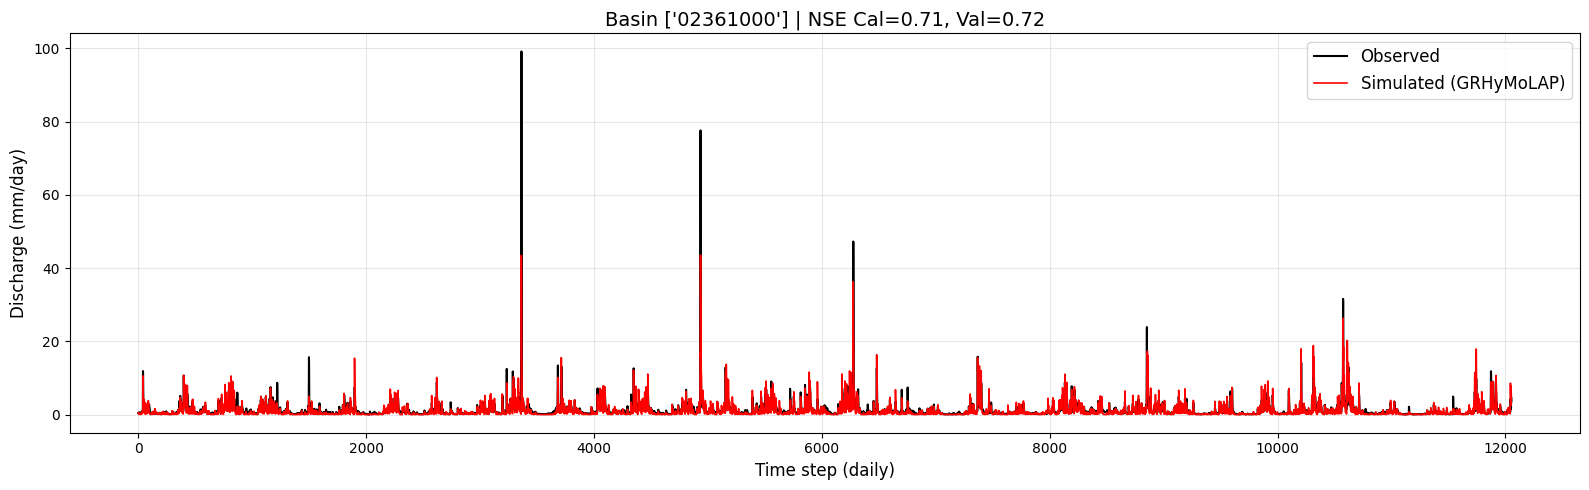

In [ ]:
import matplotlib.pyplot as plt

# ===============================
# Identify the bassin 569
# ===============================
stations = list(results_GRHyMoLAP.keys())
station_569 = ['02361000']

res = results_GRHyMoLAP['02361000']
Q_obs = res["Q_obs"]
Qsim = res["Qsim"]

# ===============================
# Plot Observed vs Simulated
# ===============================
plt.figure(figsize=(16,5))
plt.plot(Q_obs, label="Observed", color="black", linewidth=1.5)
plt.plot(Qsim, label="Simulated (GRHyMoLAP)", color="red", linewidth=1.2)

plt.title(f"Basin {station_569} | NSE Cal={res['NSE_cal']:.2f}, Val={res['NSE_val']:.2f}", fontsize=14)
plt.xlabel("Time step (daily)", fontsize=12)
plt.ylabel("Discharge (mm/day)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **GR4J**

In [ ]:
!pip install git+https://github.com/kratzert/RRMPG.git

  Cloning https://github.com/kratzert/RRMPG.git to /tmp/pip-req-build-18u9ahl3
  Running command git clone --filter=blob:none --quiet https://github.com/kratzert/RRMPG.git /tmp/pip-req-build-18u9ahl3
  Resolved https://github.com/kratzert/RRMPG.git to commit 7de78c25acc1c255d2acaf739d65e9ce7bbd60c3
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
  Created wheel for rrmpg: filename=rrmpg-0.1.1-py3-none-any.whl size=609986 sha256=aa495f77d4557fe246baf4926865520f47d68206a19e4c3a39ba43982a7de119
  Stored in directory: /tmp/pip-ephem-wheel-cache-jz_opwon/wheels/7d/ec/25/408ea8f9d8a1aff931ffd2c082074611b43cc13f5ec46e46b3
Successfully built rrmpg


In [ ]:
from rrmpg.models import GR4J

In [ ]:
import numpy as np
from scipy.optimize import minimize

b1_ratio = 0.7
max_missing_ratio = 1
results_GR4J = {}

# Liste des stations à exclure
stations_to_skip = [""]

# Sélection des stations valides
stations = [s for s in q_mm_per_day.station_id.values if s not in stations_to_skip]

# période d'étude
start_date = "1981-01-01"
end_date = "2013-12-31"

q_mm_per_day_recent = q_mm_per_day.sel(time=slice(start_date, end_date))
ds_recent = ds.sel(time=slice(start_date, end_date)).load()


for i, station_id in enumerate(stations, 1):

    print(f"\n=== Station {station_id} ===, Number = {i}")

    # --- 1. Débits observés ---
    Q_obs = q_mm_per_day_recent.sel(station_id=station_id).to_numpy()

    # --- 2. Forcing ---
    P = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    base_PET = priestley_taylor_pet(ds_recent, station_id, alpha=1.0)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data).")
        continue

    missing_count = np.sum(np.isnan(Q_obs))
    missing_ratio = missing_count / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    # --- split calibration / validation ---
    b1 = int(N * b1_ratio)
    Q_train = Q_obs[:b1]
    P_train = P[:b1]
    PET_train = base_PET[:b1]

    # --- créer modèle une fois ---
    model = GR4J()

    # --- objective function ---
    def objective_alpha(params, P_train, PET_train, Q_obs_train):
        x1, x2, x3, x4, alpha = params
        param_dict = dict(zip(model.get_parameter_names(), [x1, x2, x3, x4]))
        model.set_params(param_dict)

        PET_adj = alpha * PET_train
        try:
            Q_sim = model.simulate(P_train, PET_adj).flatten()
            nse = NSE(Q_obs_train, Q_sim)
            return 1 - nse if np.isfinite(nse) else 1e9
        except Exception:
            return 1e9

    # --- multi-start optimisation ---
    initial_guesses = [
        [350, 0, 90, 2, 1.5],
        [500, 1, 200, 3, 1.2],
        [200, -1, 100, 1.5, 1.8],
        [1000, 2, 300, 2.5, 1.0],
        [800, -2, 150, 1.8, 1.6]
    ]

    best_res = None
    best_val = float("inf")

    # ⚠️ Suppression des bornes sur alpha
    bounds = [
        (1, 5000),   # x1
        (-15, 15),   # x2
        (1, 1000),   # x3
        (0.5, 5),    # x4
        (None, None) # alpha libre
    ]

    for guess in initial_guesses:
        try:
            res = minimize(
                objective_alpha,
                guess,
                args=(P_train, PET_train, Q_train),
                method="L-BFGS-B",
                bounds=bounds,
                options={'maxiter': 2000, 'disp': False}
            )
            if res.fun < best_val:
                best_val = res.fun
                best_res = res
        except Exception as e:
            print(f"⚠️ Optimization failed for guess {guess}: {e}")
            continue

    if best_res is None:
        print("⚠️ No successful optimization for this station.")
        continue

    x1, x2, x3, x4, alpha_best = best_res.x

    # --- PET ajustée ---
    PET_full = alpha_best * base_PET

    # --- simulation complète ---
    param_dict = dict(zip(model.get_parameter_names(), [x1, x2, x3, x4]))
    model.set_params(param_dict)
    Qsim = model.simulate(P, PET_full).flatten()

    # --- metrics ---
    NSE_cal = NSE(Q_train, Qsim[:b1])
    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    RMSE_train = RMSE(Q_train, Qsim[:b1])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    # --- stockage ---
    results_GR4J[station_id] = {
        "params": [x1, x2, x3, x4, alpha_best],
        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_train,
        "RMSE_val": RMSE_val,
        "Qsim": Qsim,
        "PET_adj": PET_full,
        "Q_obs": Q_obs,
        "missing_ratio": missing_ratio,
        "missing_count": missing_count,
    }

    print(f"✅ Cal RMSE: {RMSE_train:.3f}, Val RMSE: {RMSE_val:.3f}")
    print(f"   Cal NSE: {NSE_cal:.3f}, Val NSE: {NSE_val:.3f}")
    print(f"   Params: x1={x1:.2f}, x2={x2:.2f}, x3={x3:.2f}, x4={x4:.2f}, alpha={alpha_best:.2f}")

print(f"\n✅ Simulation complete for {len(results_GR4J)} valid basins.")


=== Station 08324000 ===, Number = 1


/tmp/ipykernel_538/47819975.py:90: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
/tmp/ipykernel_538/47819975.py:90: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


✅ Cal RMSE: 0.226, Val RMSE: 0.150
   Cal NSE: 0.246, Val NSE: 0.229
   Params: x1=594.11, x2=2.25, x3=165.28, x4=5.00, alpha=0.58

=== Station 08380500 ===, Number = 2
✅ Cal RMSE: 0.436, Val RMSE: 0.537
   Cal NSE: 0.323, Val NSE: 0.179
   Params: x1=492.87, x2=-7.98, x3=89.67, x4=1.12, alpha=0.22

=== Station 08267500 ===, Number = 3
✅ Cal RMSE: 1.048, Val RMSE: 0.930
   Cal NSE: 0.148, Val NSE: 0.120
   Params: x1=517.86, x2=14.61, x3=474.58, x4=5.00, alpha=0.49

=== Station 08378500 ===, Number = 4
✅ Cal RMSE: 0.813, Val RMSE: 0.603
   Cal NSE: 0.129, Val NSE: 0.210
   Params: x1=707.05, x2=8.72, x3=309.99, x4=5.00, alpha=0.56

=== Station 08377900 ===, Number = 5
✅ Cal RMSE: 0.987, Val RMSE: 0.754
   Cal NSE: 0.122, Val NSE: 0.154
   Params: x1=778.99, x2=7.21, x3=307.02, x4=2.22, alpha=0.53

=== Station 08269000 ===, Number = 6
✅ Cal RMSE: 0.665, Val RMSE: 0.469
   Cal NSE: 0.219, Val NSE: 0.223
   Params: x1=431.40, x2=6.33, x3=241.03, x4=5.00, alpha=0.48

=== Station 08271000 =

In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_GR4J.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_GR4J.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_GR4J.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_GR4J.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.615, 5th percentile: 0.1298, 95th percentile: 0.8279
MEAN NSE_CAL: 0.5495394196263389
MIN NSE_CAL: -0.5144506966820184
MAX NSE_CAL: 0.923517101745304

--- RMSE Calibration ---
RMSE Calibration -> Median: 1.360, 5th percentile: 0.2007, 95th percentile: 3.9292
MEAN RMSE_CAL: 1.5669063773588718
MIN RMSE_CAL: 0.044058109072074435
MAX RMSE_CAL: 9.208154342900613


================= VALIDATION =================

NSE Validation -> Median: 0.563, 5th percentile: 0.0437, 95th percentile: 0.8092
MEAN NSE_VAL: 0.4592131911582275
MIN NSE_VAL: -11.73189932719829
MAX NSE_VAL: 0.9047803521575001

--- RMSE Validation ---
RMSE Validation -> Median: 1.305, 5th percentile: 0.2170, 95th percentile: 4.2271
MEAN RMSE_VAL: 1.5922745758490466
MIN RMSE_VAL: 0.03624278516799845
MAX RMSE_VAL: 11.063137357485774


## Parameters distribution: GRHyMoLAP

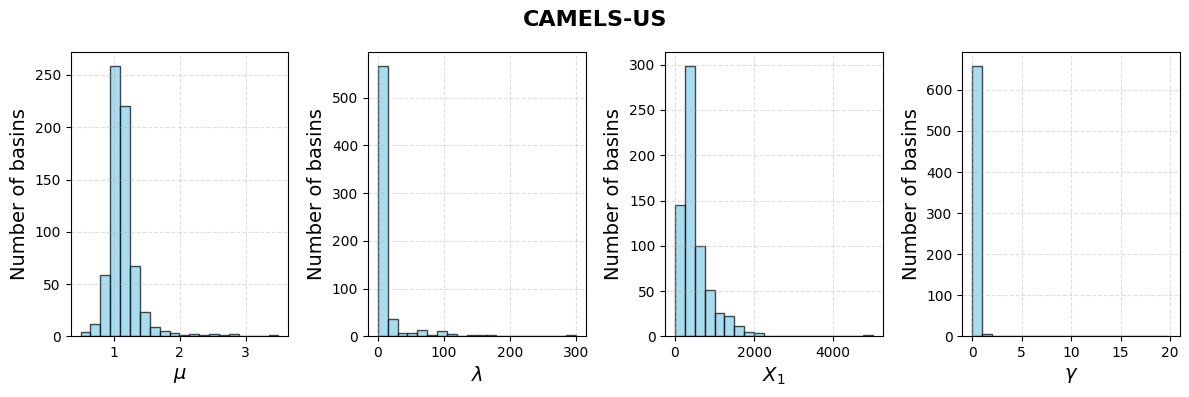

In [ ]:
import matplotlib.pyplot as plt

MU_list = [results_GRHyMoLAP[s]["params"][0] for s in results_GRHyMoLAP]
LAMBDA_list = [results_GRHyMoLAP[s]["params"][1] for s in results_GRHyMoLAP]
X1_list = [results_GRHyMoLAP[s]["params"][2] for s in results_GRHyMoLAP]
GAMMA_list = [results_GRHyMoLAP[s]["params"][3] for s in results_GRHyMoLAP]

param_names = [r"$\mu$", r"$\lambda$", r"$X_1$", r"$\gamma$"]
param_values = [MU_list, LAMBDA_list, X1_list, GAMMA_list]

plt.figure(figsize=(12,4))

for i, values in enumerate(param_values):
    plt.subplot(1,4,i+1)
    plt.hist(values, bins=20, color="skyblue", edgecolor="k", alpha=0.7)
    plt.xlabel(param_names[i], fontsize=14)
    plt.ylabel("Number of basins", fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("CAMELS-US", fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout()
plt.savefig("parameter_US.jpeg", dpi=700)
#files.download("parameter_US.jpeg")  # si tu veux télécharger
plt.show()

## GR4J_X1 vs. GRHyMoLAP_X1

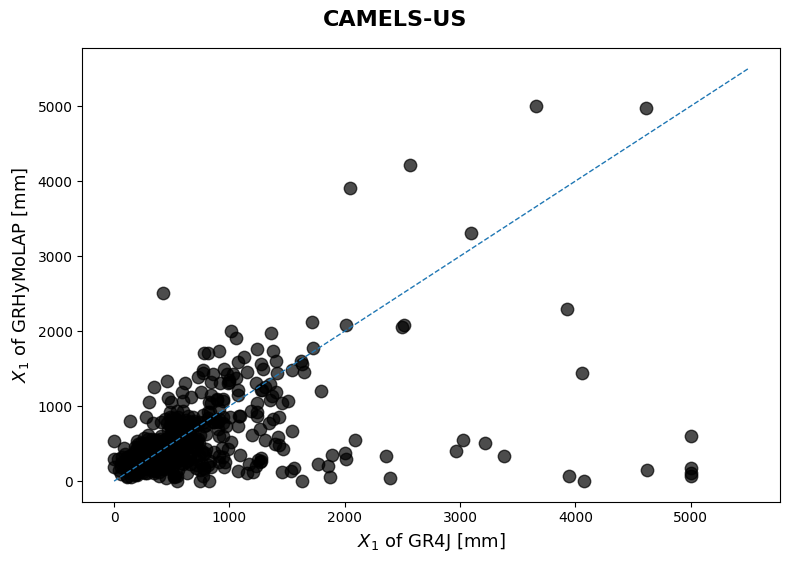

In [ ]:
from scipy.stats import pearsonr

# ============================================
# Prepare X1 values for the selected stations
# ============================================
X1_GR4J_all = np.array([results_GR4J[s]["params"][0] for s in stations])
X1_GRHyMoLAP_all = np.array([results_GRHyMoLAP[s]["params"][2] for s in stations])

# Global R²
r, _ = pearsonr(X1_GR4J_all, X1_GRHyMoLAP_all)
r2_global = r**2

# ============================================
# Scatter plot
# ============================================
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(X1_GR4J_all, X1_GRHyMoLAP_all, s=80, color="black", alpha=0.7)

# 1:1 line
lims = [min(X1_GR4J_all.min(), X1_GRHyMoLAP_all.min())*0.9,
        max(X1_GR4J_all.max(), X1_GRHyMoLAP_all.max())*1.1]
ax.plot(lims, lims, '--', color='tab:blue', linewidth=1)

# Titre général
fig.suptitle("CAMELS-US", fontsize=16, fontweight='bold', y=0.93)

ax.set_xlabel(r"$X_1$ of GR4J [mm]", fontsize=13)
ax.set_ylabel(r"$X_1$ of GRHyMoLAP [mm]", fontsize=13)

plt.grid(False)
plt.tight_layout(rect=[0,0,1,0.95])

plt.savefig("scatter_X1_CAMELS_US.jpeg", dpi=700)
#files.download("scatter_X1_CAMELS_US.jpeg")
plt.show()

## Scatter_Plots

In [ ]:
import pandas as pd

# Path to the Excel file stored in Google Drive
file_path1 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Paper1/US/HyMoLAP_validation_metrics.xlsx"
file_path2 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Paper1/US/GRHyMoLAP_validation_metrics.xlsx"
file_path3 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Paper1/US/GR4J_validation_metrics.xlsx"
file_path4 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Paper1/US/HBV_validation_metrics.xlsx"

# Read the Excel file (by default it loads the first sheet)
df1 = pd.read_excel(file_path1)
df2 = pd.read_excel(file_path2)
df3 = pd.read_excel(file_path3)
df4 = pd.read_excel(file_path4)

# Display the column names to verify the structure of the dataset
print(df1.columns)

# Extract the NSE values for the validation period
HyMoLAP = df1["NSE_val"]
GRHyMoLAP = df2["NSE_val"]
GR4J = df3["NSE_val"]
HBV = df4["NSE_val"]

Index(['station_id', 'MU', 'LAMBDA', 'alpha', 'NSE_val', 'NNSE_val',
       'RMSE_val', 'PBIAS_val', 'FHV_val', 'FLV_val', 'missing_ratio',
       'missing_count'],
      dtype='object')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

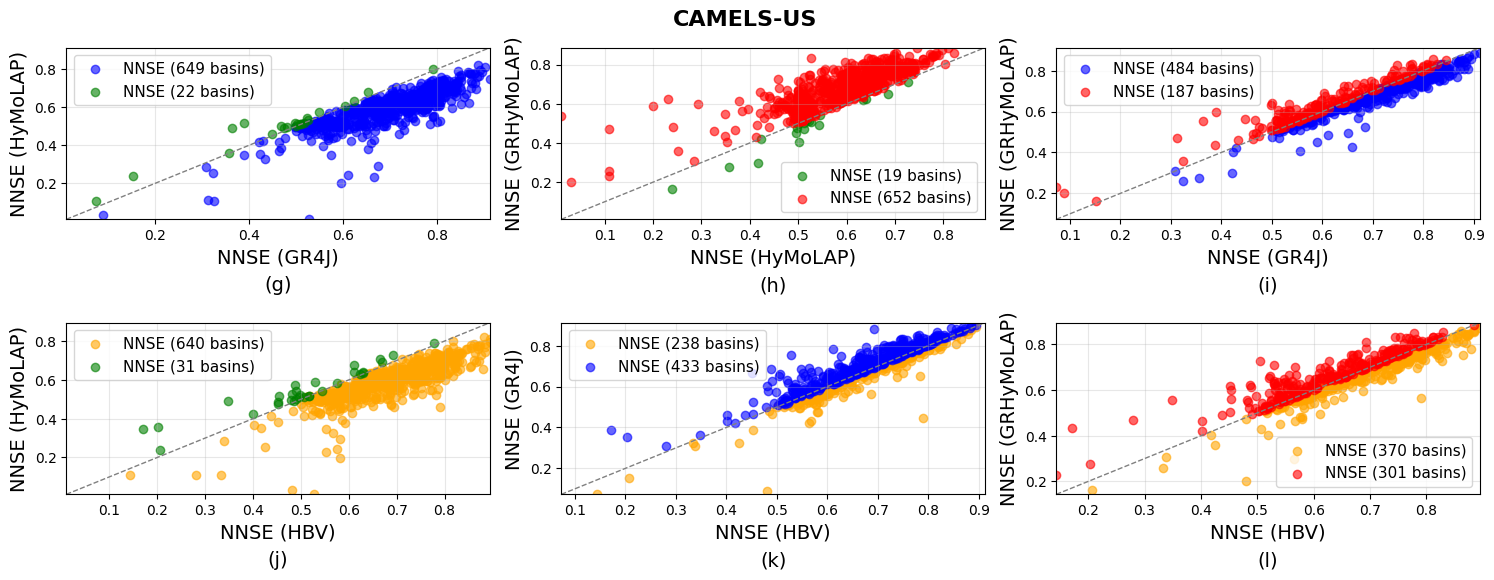

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 📌NNSE for each model
# ===============================
def calc_nnse(nse_array):
    return 1 / (2 - nse_array)

GRHyMoLAP_nnse = calc_nnse(GRHyMoLAP)
GR4J_nnse = calc_nnse(GR4J)
HyMoLAP_nnse = calc_nnse(HyMoLAP)
HBV_nnse = calc_nnse(HBV)

# ===============================
# 📌 Colors of modèles
# ===============================
colors = {
    'GRHyMoLAP': 'red',
    'GR4J': 'blue',
    'HyMoLAP': 'green',
    'HBV': 'orange'
}

# ===============================
# 📌 Function scatter for NNSE
# ===============================
def scatter_points_nnse(ax, x, y, xlabel_model, ylabel_model, legend_loc='upper left'):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]

    if len(x) == 0 or len(y) == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=14)
        ax.axis("off")
        return

    above = y > x
    below = ~above

    # Scatter points
    ax.scatter(x[below], y[below], c=colors[xlabel_model], alpha=0.6,
               label=f"NNSE ({below.sum()} basins)")
    ax.scatter(x[above], y[above], c=colors[ylabel_model], alpha=0.6,
               label=f"NNSE ({above.sum()} basins)")

    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, '--', color='gray', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(f"NNSE ({xlabel_model})", fontsize=14)
    ax.set_ylabel(f"NNSE ({ylabel_model})", fontsize=14)

    ax.legend(loc=legend_loc, fontsize=11)
    ax.grid(True, alpha=0.3)

# ===============================

pairs_ordered = [
    ('GR4J','HyMoLAP'),        # (a)
    ('HyMoLAP','GRHyMoLAP'),   # (b)
    ('GR4J','GRHyMoLAP'),      # (c)
    ('HBV','HyMoLAP'),         # (d)
    ('HBV','GR4J'),            # (e)
    ('HBV','GRHyMoLAP')        # (f)
]

# ===============================

legend_locs = []
for i, (x_model, y_model) in enumerate(pairs_ordered):
    if i == 5:
        legend_locs.append('lower right')  # last subplot
    elif x_model == 'HyMoLAP':
        legend_locs.append('lower right')
    elif y_model == 'HyMoLAP':
        legend_locs.append('upper left')
    else:
        legend_locs.append('upper left')

# ===============================

fig, axes = plt.subplots(2,3, figsize=(15,6))
axes = axes.flatten()

#
fig.suptitle("CAMELS-US", fontsize=16, fontweight='bold', y=0.98)

#
nnse_data = {
    'GRHyMoLAP': GRHyMoLAP_nnse,
    'GR4J': GR4J_nnse,
    'HyMoLAP': HyMoLAP_nnse,
    'HBV': HBV_nnse
}

for i, ((x_model, y_model), loc) in enumerate(zip(pairs_ordered, legend_locs)):
    scatter_points_nnse(
        axes[i],
        nnse_data[x_model],
        nnse_data[y_model],
        x_model,
        y_model,
        legend_loc=loc
    )

# ===============================
# 📌 Ajouter les labels (a-f)
# ===============================
labels = ['(g)','(h)','(i)','(j)','(k)','(l)']
for ax, label in zip(axes, labels):
    ax.text(0.5, -0.33, label, transform=ax.transAxes,
            ha='center', va='top', fontsize=14)

plt.tight_layout()
plt.savefig("NNSE_scatter_CAMELS-US.jpeg", dpi=700, format="jpeg")
#files.download("NNSE_scatter_CAMELS-US.jpeg")
plt.show()

In [ ]:
import numpy as np

# Masque for ignoring NaN
mask = (~np.isnan(GR4J_nnse)) & (~np.isnan(GRHyMoLAP_nnse))

# Difference GR4J - GRHyMoLAP
diff = GR4J_nnse[mask] - GRHyMoLAP_nnse[mask]

# Bassins where GR4J > GRHyMoLAP
gr4j_better_mask = diff > 0

# Bassins where GR4J > GRHyMoLAPbut with difference ≤ 0.03
small_diff_mask = (diff <= 0.03) & gr4j_better_mask

print(f"Number of basins where GR4J > GRHyMoLAP: {np.sum(gr4j_better_mask)}")
print(f"Among these, number with difference ≤ 0.03: {np.sum(small_diff_mask)}")
print(f"Fraction: {np.sum(small_diff_mask)/np.sum(gr4j_better_mask)*100:.1f}%")

Number of basins where GR4J > GRHyMoLAP: 484
Among these, number with difference ≤ 0.03: 323
Fraction: 66.7%


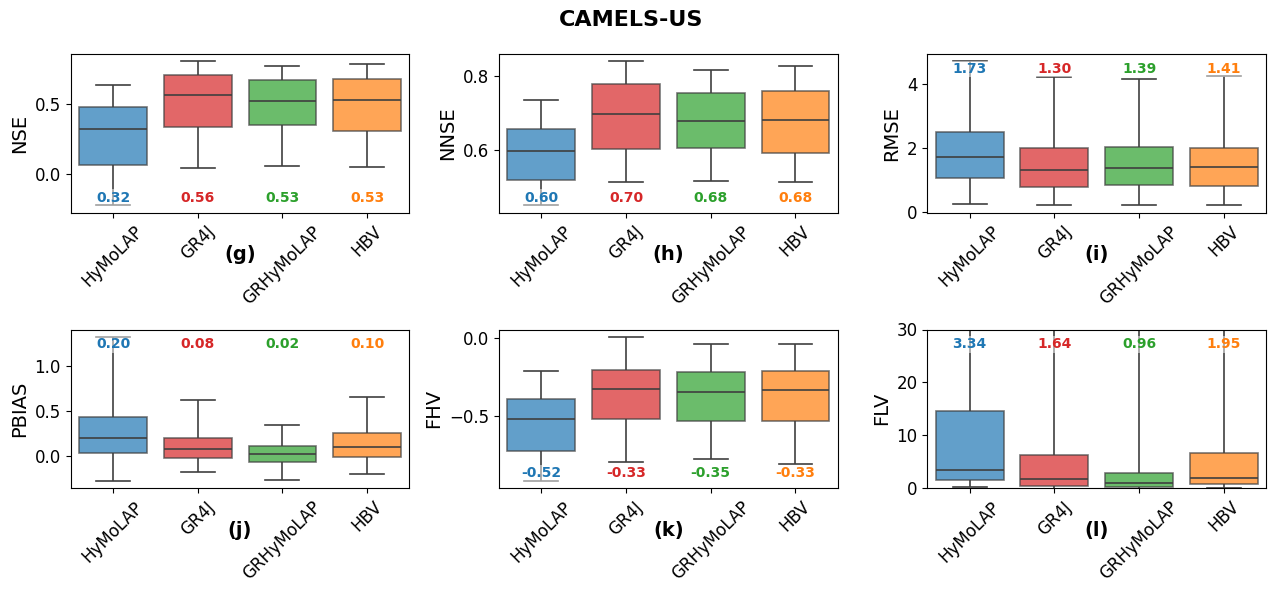

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import files

# -------------------------
models = {
    'HyMoLAP': df1,
    'GR4J': df3,
    'GRHyMoLAP': df2,
    'HBV': df4
}

model_order = ['HyMoLAP','GR4J','GRHyMoLAP','HBV']
colors_list = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
colors_dict = dict(zip(model_order, colors_list))
bottom_metrics = ['NSE','NNSE','FHV']

#
subplot_labels = ['(g)','(h)','(i)','(j)','(k)','(l)']

# -------------------------
# Metrics
# -------------------------
metrics = ['NSE_val', 'NNSE_val', 'RMSE_val', 'PBIAS_val', 'FHV_val', 'FLV_val']

# -------------------------
#  DataFrame
# -------------------------
dfs = []

for model_name, df_model in models.items():

    df_tmp = df_model.copy()
    df_tmp['Model'] = model_name

    cols_to_keep = [c for c in metrics if c in df_tmp.columns] + ['Model']
    df_tmp = df_tmp[cols_to_keep]

    df_tmp.columns = [c.replace('_val','') for c in df_tmp.columns]

    dfs.append(df_tmp)

df_all = pd.concat(dfs, ignore_index=True)

# -------------------------
#  figure
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.flatten()

for i, metric in enumerate([m.replace('_val','') for m in metrics]):

    ax = axes[i]

    valid_models = [m for m in model_order if df_all[df_all['Model']==m][metric].notna().any()]

    if not valid_models:
        ax.text(0.5,0.5,"No data",ha='center',va='center',fontsize=14)
        ax.axis('off')
        continue

    # boxplot
    sns.boxplot(
        x='Model',
        y=metric,
        data=df_all[df_all['Model'].isin(valid_models)],
        order=valid_models,
        whis=[5,95],
        showfliers=False,
        linewidth=1.2,
        ax=ax
    )

    #  box
    for patch, model in zip(ax.patches, valid_models):
        patch.set_facecolor(colors_dict[model])
        patch.set_alpha(0.7)

    if metric=='FLV':
        ax.set_ylim(0,30)

    # axes
    ax.set_xlabel('')
    ax.set_ylabel(metric, fontsize=14)

    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Median
    for j, model in enumerate(model_order):

        vals = df_all[df_all['Model']==model][metric].dropna()

        if len(vals)==0:
            continue

        med_val = np.median(vals)

        x_coord = valid_models.index(model) if model in valid_models else j

        ylim = ax.get_ylim()

        if metric in bottom_metrics:
            y_coord = ylim[0] + 0.05*(ylim[1]-ylim[0])
            va = 'bottom'
        else:
            y_coord = ylim[1] - 0.05*(ylim[1]-ylim[0])
            va = 'top'

        ax.text(
            x_coord,
            y_coord,
            f"{med_val:.2f}",
            fontsize=10,
            ha='center',
            va=va,
            fontweight='bold',
            color=colors_dict[model],
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
        )

    # -------------------------
    # lettre subplot (a,b,c,d,e,f)
    # -------------------------
    ax.text(
        0.5,
        -0.30,
        subplot_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        ha='center'
    )

fig.suptitle("CAMELS-US", fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.99])

plt.savefig("boxpplot_US.jpeg", dpi=700)

#files.download("boxpplot_US.jpeg")

plt.show()